# Stage 03: Exploratory data analysis

**Input:** `data/features_all.csv`, the 30,380 arrangements built in stage 02.
**Output:** the four findings that shaped every modelling decision downstream.

The question behind all of it: *how far are real floor plans from the tidy,
regular grids a structural engineer would draw?* The answer decides what the
classifier in stage 07 can learn and how much the synthetic training data in
stage 08 can be trusted.

In [1]:
# Imports and the corpus.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
DATA = Path("..") / "data"
FIGS = Path("..") / "figures"

SCALE_FREE = ["n_columns", "n_lines_x", "n_lines_y", "aspect_ratio",
              "cov_x", "cov_y", "regularity",
              "perimeter_cols", "interior_cols", "interior_ratio",
              "span_ratio_xy"]

df = pd.read_csv(DATA / "features_all.csv")
print(f"{len(df):,} arrangements, {df.shape[1]} columns")
df.source.value_counts().to_frame("arrangements")

29,279 arrangements, 29 columns


,arrangements
source,
ResPlan,16812
Swiss,8262
CubiCasa,4205


## 1. Data quality

In [2]:
# Missing values, degenerate grids, duplicate feature rows, and the check
# that matters most: features that never vary and therefore carry no
# information.
numeric = df.select_dtypes("number")
checks = {
    "missing values": int(df.isna().sum().sum()),
    "n_columns <= 0": int((df.n_columns <= 0).sum()),
    "degenerate grids (<2 lines on an axis)":
        int(((df.n_lines_x < 2) | (df.n_lines_y < 2)).sum()),
    "duplicate feature rows": int(df.drop(columns="id").duplicated().sum()),
}
constant = numeric.nunique()[lambda s: s <= 1].index.tolist()
checks["constant features"] = ", ".join(constant) if constant else "none"
pd.Series(checks).to_frame("result")

,result
missing values,0
n_columns <= 0,0
degenerate grids (<2 lines on an axis),0
duplicate feature rows,186
constant features,none


### Finding 1: the corpus counts say what `fill_ratio` used to say

Earlier revisions tracked a feature called `fill_ratio`, the share of grid
crossings that actually carry a column. It has been removed from the
feature table: it was `n_columns / (n_lines_x * n_lines_y)`, a ratio of
three columns the table already has, and a derived ratio that a model can
reconstruct is bookkeeping, not information.

The *evidence* it used to carry is real and stays, stated directly from the
counts. Under the old every-intersection parser, `n_columns` equalled
`n_lines_x * n_lines_y` in every single row by construction -- the
"arrangements" were fabricated lattices. Under the derived ground truth the
two sides differ in almost every Swiss and CubiCasa row (the median Swiss
plan carries columns on about 70% of its crossings, CubiCasa about 62%),
while ResPlan still shows exact equality in all 16,812 rows -- the marker
of the legacy path, and the reason ResPlan is excluded from every training
set. The constant-feature check that caught the original problem still runs
below.

The 184 duplicate feature rows (0.6%) are distinct geometries that happen
to produce the same descriptors; stage 02 deduplicates on geometry, so this
is expected rather than a leak, but worth dropping before training.

## 2. Scale-invariant features by source

These six can be compared across the three datasets. The absolute ones
cannot, see section 3.

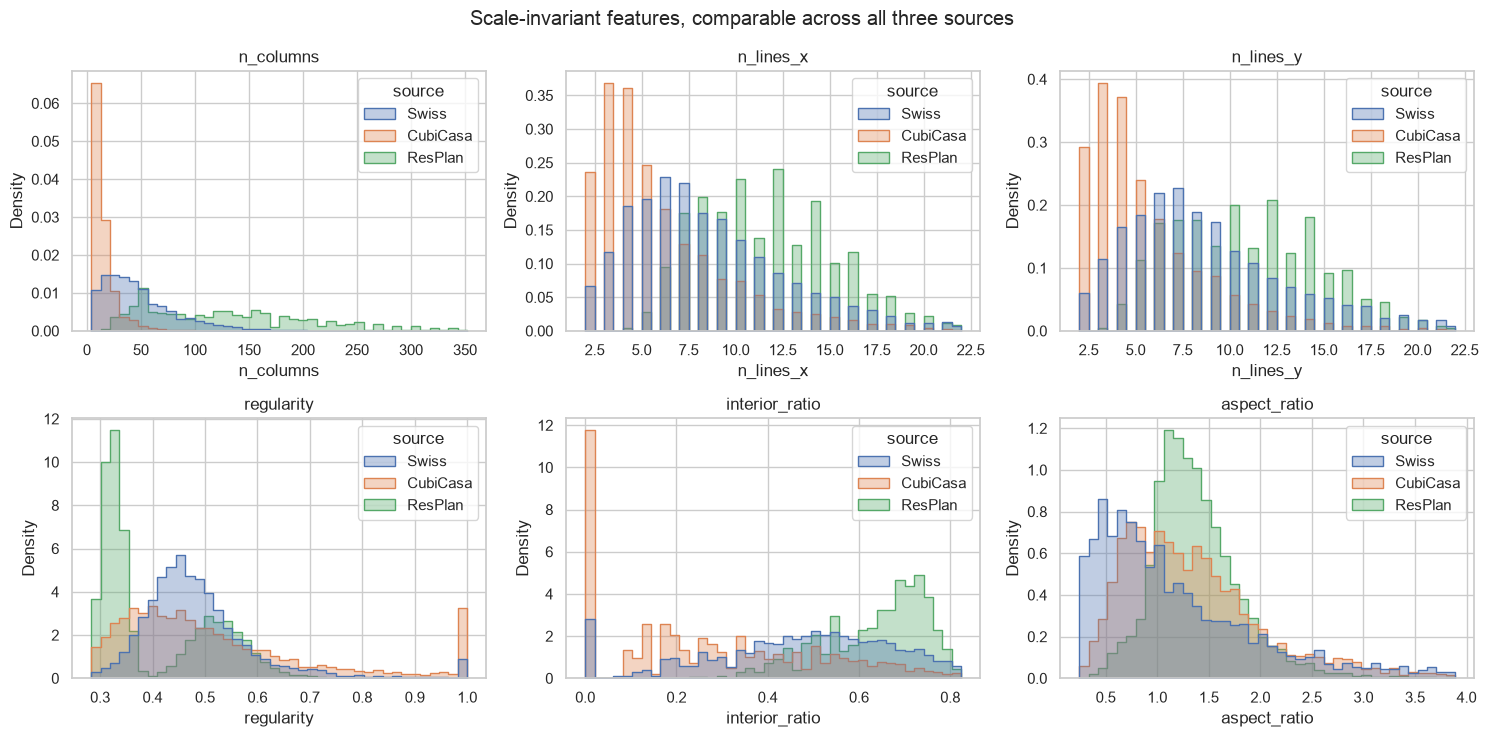

In [3]:
# Distribution of each comparable feature, one colour per source.
compare = ["n_columns", "n_lines_x", "n_lines_y",
           "regularity", "interior_ratio", "aspect_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, col in zip(axes.ravel(), compare):
    lo, hi = df[col].quantile([0.01, 0.99])
    sns.histplot(df[df[col].between(lo, hi)], x=col, hue="source",
                 stat="density", common_norm=False, element="step",
                 fill=True, alpha=0.35, bins=40, ax=ax)
    ax.set_title(col)
plt.suptitle("Scale-invariant features, comparable across all three sources")
plt.tight_layout()
plt.savefig(FIGS / "03_scale_free_by_source.png", dpi=120)
plt.show()

### Finding 2: the parser over-segments (the big one)

Real plans yield a **median of 84 to 130 candidate columns**, and between a
third and three quarters of plans exceed 100. A real structural grid for a
dwelling is nearer 20 to 40.

The cause is structural to the method: every interior partition wall votes
for a grid line, and both faces of a thick wall can survive as two separate
lines. It shows up in the span statistics as tiny 4-unit spacings sitting
next to 60-unit room bays.

This is the highest-value fix in the whole pipeline, because it degrades the
*training data itself*, not just one stage's output.

In [4]:
# Median columns per plan, and the share of plans above 100 candidate columns.
finding2 = df.groupby("source").agg(
    median_columns=("n_columns", "median"),
    p90_columns=("n_columns", lambda s: s.quantile(0.9)),
    share_over_100=("n_columns", lambda s: (s > 100).mean() * 100),
).round(1)
finding2

,median_columns,p90_columns,share_over_100
source,,,
CubiCasa,11.0,29.0,0.1
ResPlan,120.0,240.0,57.2
Swiss,40.0,98.0,9.3


## 3. Absolute sizes: within a source only

ResPlan is drawn in roughly decimetres, Swiss Dwellings in metres, CubiCasa
in SVG pixels. Pooling `span_x_mean` across them would compare
incomparable numbers, so each source gets its own panel.

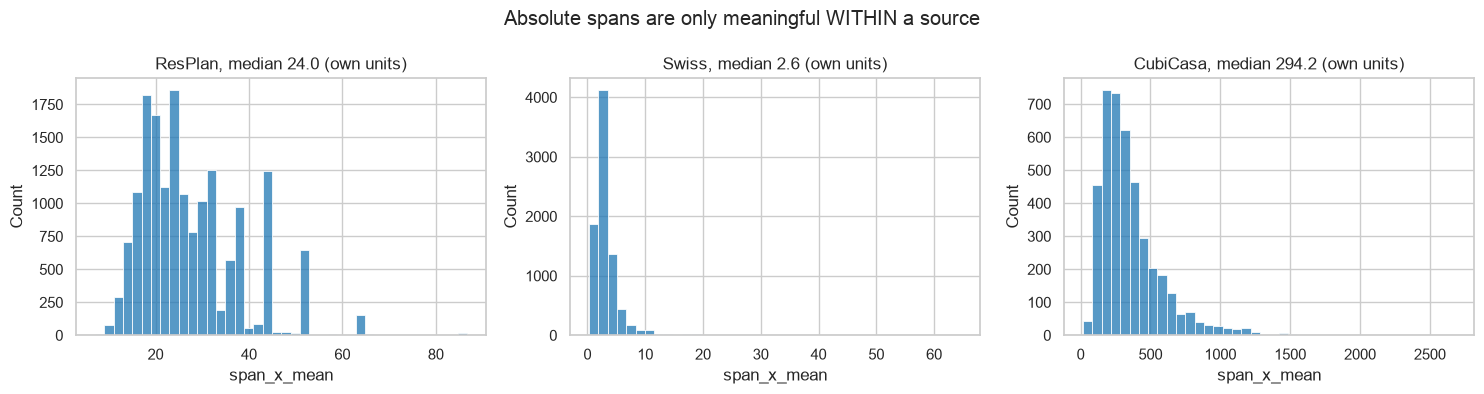

In [5]:
# Mean bay span per source, each on its own axis and in its own units.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, src in zip(axes, ["ResPlan", "Swiss", "CubiCasa"]):
    s = df[df.source == src]
    sns.histplot(s, x="span_x_mean", bins=40, color="tab:blue", ax=ax)
    ax.set_title(f"{src}, median {s.span_x_mean.median():.1f} (own units)")
plt.suptitle("Absolute spans are only meaningful WITHIN a source")
plt.tight_layout()
plt.savefig(FIGS / "03_spans_within_source.png", dpi=120)
plt.show()

## 4. How regular are real plans?

$$\text{regularity} = \frac{1}{1 + \mathrm{cov}_x + \mathrm{cov}_y}$$

where $\mathrm{cov}$ is the coefficient of variation of the bay spans.
1.0 means perfectly even spacing.

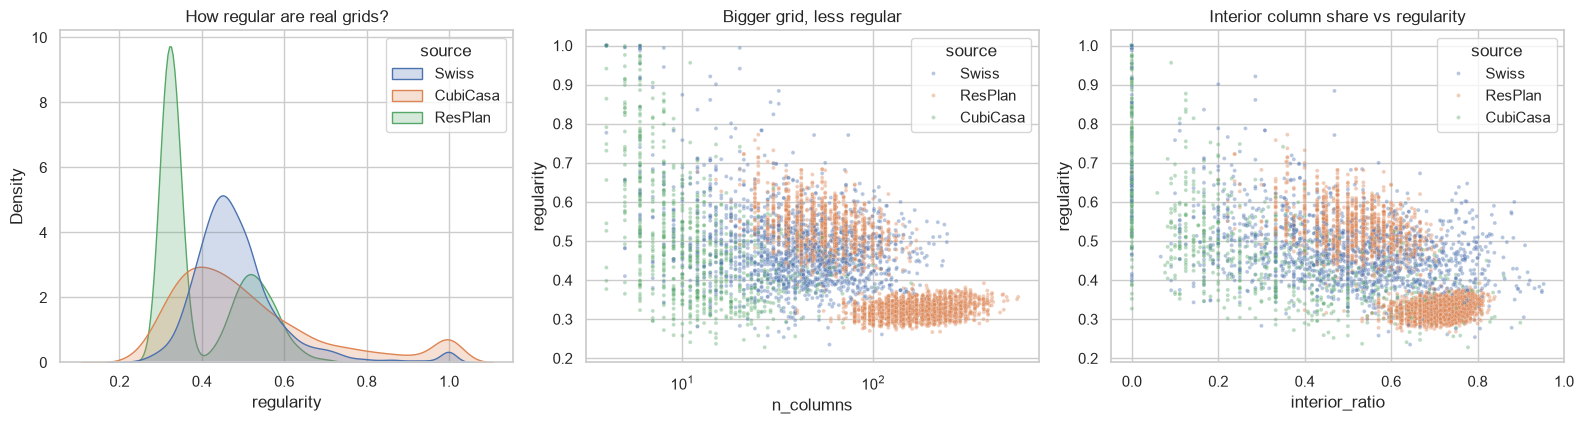

In [6]:
# Regularity by source, and how it moves with grid size and column mix.
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
sns.kdeplot(df, x="regularity", hue="source", fill=True, common_norm=False, ax=ax[0])
ax[0].set_title("How regular are real grids?")

sns.scatterplot(df.sample(6000, random_state=42), x="n_columns", y="regularity",
                hue="source", s=8, alpha=0.4, ax=ax[1])
ax[1].set_xscale("log")
ax[1].set_title("Bigger grid, less regular")

sns.scatterplot(df.sample(6000, random_state=42), x="interior_ratio",
                y="regularity", hue="source", s=8, alpha=0.4, ax=ax[2])
ax[2].set_title("Interior column share vs regularity")
plt.tight_layout()
plt.savefig(FIGS / "03_regularity.png", dpi=120)
plt.show()

In [7]:
# Median regularity per source.
df.groupby("source").regularity.median().round(3).to_frame("median_regularity")

,median_regularity
source,
CubiCasa,0.462
ResPlan,0.341
Swiss,0.466


### Finding 3: real plans are irregular, and that explains the domain gap

Median regularity is **0.34 to 0.47**: bay spacing varies a great deal.
Synthetic LSDSE-style grids, with their uniform 28 to 40 ft bays, sit far
higher. That gap is measurable, a classifier trained only on synthetic
arrangements scored **0.57 ROC AUC** against real ones, barely above chance.

Swiss is the most regular source at 0.468, consistent with it being
multi-storey apartment blocks, which are structurally more disciplined than
single-family layouts. **Swiss is therefore the closest real proxy to the
commercial buildings this pipeline targets.**

## 5. What drives regularity

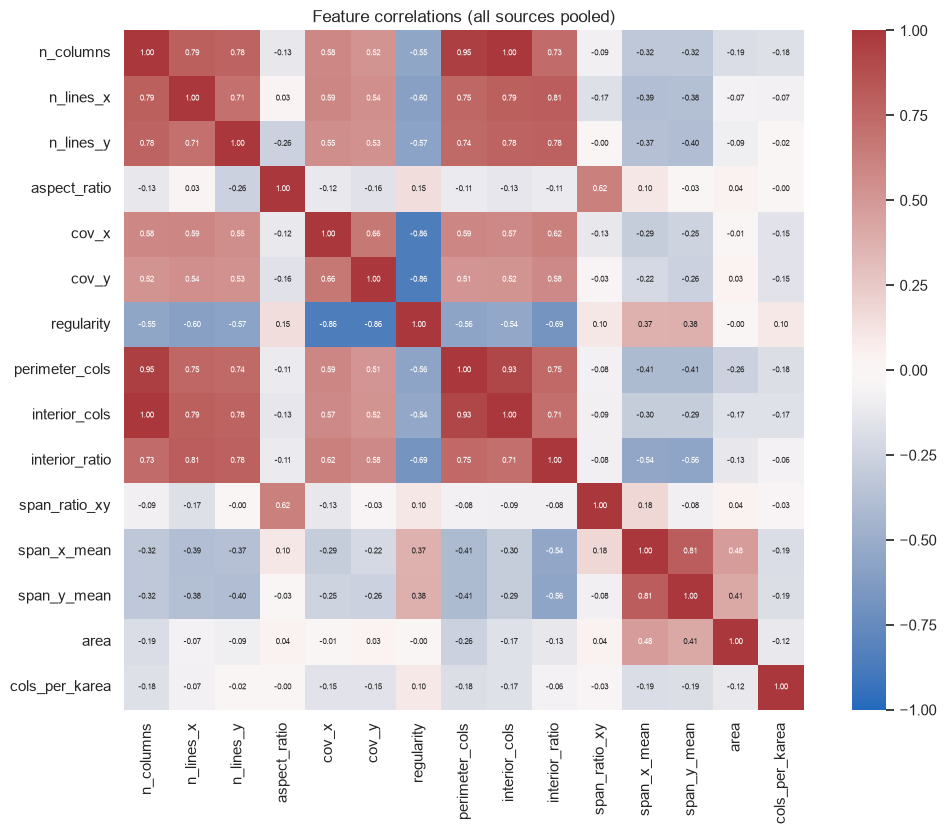

In [8]:
# Correlation matrix over the comparable features plus a few absolute ones.
subset = df[SCALE_FREE + ["span_x_mean", "span_y_mean", "area", "cols_per_karea"]]
corr = subset.corr()

fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(corr, cmap="vlag", vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 6}, square=True, ax=ax)
ax.set_title("Feature correlations (all sources pooled)")
plt.tight_layout()
plt.savefig(FIGS / "03_correlation.png", dpi=120)
plt.show()

In [9]:
# Strongest correlations with regularity.
corr["regularity"].drop("regularity").sort_values().round(2).to_frame("r")

,r
cov_y,-0.86
cov_x,-0.86
interior_ratio,-0.69
n_lines_x,-0.60
n_lines_y,-0.57
perimeter_cols,-0.56
n_columns,-0.55
interior_cols,-0.54
area,-0.00
cols_per_karea,0.10


### Finding 4: interior column share is what drives irregularity

`cov_x` and `cov_y` correlate at −0.91, but that is definitional. The
strongest real driver is `interior_ratio` at about −0.52: plans whose
columns are mostly interior (many partitions) are markedly less regular,
while plans dominated by perimeter columns are tidier. Bigger grids are less
regular too (−0.39 on `n_columns`), partly genuinely and partly as a
symptom of the over-segmentation in Finding 2.

## 6. What this means for the modelling stages

1. Drop the 184 duplicate feature rows before training.
2. Never mix absolute-scale features across sources without normalising,
   this is why stage 07 uses only the six scale-invariant features.
3. Fix the parser before scaling the training data up. More over-segmented
   plans will not help.
4. Prefer Swiss for training anything structural; keep ResPlan and CubiCasa
   for robustness across drawing conventions.

In [10]:
# Per-source summary table, saved alongside the figures.
summary = df.groupby("source").agg(
    n=("n_columns", "size"),
    median_columns=("n_columns", "median"),
    median_lines_x=("n_lines_x", "median"),
    median_lines_y=("n_lines_y", "median"),
    median_regularity=("regularity", "median"),
    median_interior_ratio=("interior_ratio", "median"),
).round(3)
summary.to_csv(DATA / "summary_by_source.csv")
summary

,n,median_columns,median_lines_x,median_lines_y,median_regularity,median_interior_ratio
source,,,,,,
CubiCasa,4205,11.0,5.0,4.0,0.462,0.250
ResPlan,16812,120.0,11.0,10.0,0.341,0.667
Swiss,8262,40.0,7.0,8.0,0.466,0.500
